# Data Transformation Techniques for Machine Learning

A hands-on reference notebook covering the transformation techniques you need
before feeding data into most ML models: scaling, normalization, encoding,
power/log transforms, outlier-robust methods, dimensionality-reduction-based
transforms (PCA/whitening), and time-series-specific transforms.

**Structure**
1. Setup and synthetic dataset
2. Why transform data at all (visual motivation)
3. Scaling techniques (Min-Max, Standard, MaxAbs, Robust)
4. Normalization (L1/L2/Max, row-wise vs column-wise)
5. Distribution-shaping transforms (log, Box-Cox, Yeo-Johnson, quantile)
6. Encoding categorical variables
7. Outlier-robust transformations
8. Dimensionality-reduction transforms (PCA, whitening, ZCA)
9. Time-series-specific transforms (differencing, rolling stats, lag features)
10. Putting it together: a `ColumnTransformer` pipeline
11. Summary / decision guide

Each section explains the **math**, shows a **from-scratch implementation**,
compares it against **scikit-learn**, and visualizes the effect on data.


## 1. Setup and Synthetic Dataset

We build a synthetic tabular dataset that intentionally has the properties
that make transformation necessary:

- Features on wildly different **scales** (income in dollars vs. age in years)
- A **skewed** feature (income, log-normal-like)
- A feature with **outliers**
- A **categorical** feature
- A **time-series** column for the time-series section


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler,
    Normalizer, PowerTransformer, QuantileTransformer,
    OneHotEncoder, OrdinalEncoder
)
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

N = 1000

age = np.random.normal(40, 12, N).clip(18, 90)
income = np.random.lognormal(mean=10.5, sigma=0.6, size=N)  # right-skewed, large scale
credit_score = np.random.normal(650, 80, N).clip(300, 850)
years_employed = np.random.exponential(scale=6, size=N).clip(0, 40)

# Inject outliers into income (e.g. a few very high earners)
outlier_idx = np.random.choice(N, size=15, replace=False)
income[outlier_idx] *= np.random.uniform(5, 15, size=15)

region = np.random.choice(['North', 'South', 'East', 'West'], size=N, p=[0.3, 0.25, 0.25, 0.2])
education = np.random.choice(
    ['High School', 'Bachelors', 'Masters', 'PhD'],
    size=N, p=[0.3, 0.4, 0.22, 0.08]
)

df = pd.DataFrame({
    'age': age,
    'income': income,
    'credit_score': credit_score,
    'years_employed': years_employed,
    'region': region,
    'education': education,
})

print(df.shape)
df.head()


(1000, 6)


,age,income,credit_score,years_employed,region,education
0,45.960570,84087.505013,595.985738,10.246944,East,Masters
1,38.340828,63245.560206,638.438506,24.650858,South,Bachelors
2,47.772262,37638.329884,586.606406,1.803962,West,Masters
3,58.276358,24632.892773,625.363078,20.984327,East,High School
4,37.190160,55211.911011,498.510827,3.385716,South,Bachelors


In [2]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1000.0,40.338069,11.511416,18.000000,32.228916,40.303607,47.775327,8.623278e+01
income,1000.0,51023.259462,65976.785674,6221.503142,25312.478519,38049.615765,57275.500400,1.065514e+06
credit_score,1000.0,650.183217,77.830909,408.439028,598.160031,649.979939,702.873225,8.500000e+02
years_employed,1000.0,5.804225,5.855484,0.000184,1.683680,3.964643,7.861082,3.657932e+01


## 2. Why Transform Data at All?

Most ML algorithms make implicit assumptions about the scale and distribution
of input features:

- **Distance-based models** (k-NN, k-means, SVM with RBF kernel) treat all
  features as contributing equally to a distance metric. A feature ranging
  over $[0, 200{,}000]$ will dominate one ranging over $[0, 100]$ unless
  rescaled.
- **Gradient-based models** (linear/logistic regression, neural networks)
  converge faster and more reliably when features share a similar scale,
  since gradient step sizes are otherwise dominated by high-variance
  features.
- **Regularized models** (Ridge, Lasso) penalize coefficient magnitude
  directly — that penalty is meaningless unless features are on comparable
  scales.
- **Tree-based models** (Random Forest, XGBoost) are largely scale-invariant
  (splits are threshold-based), but still benefit from encoding and
  outlier handling.

The plot below shows our raw features on their native scales — notice how
`income` visually swamps everything else.


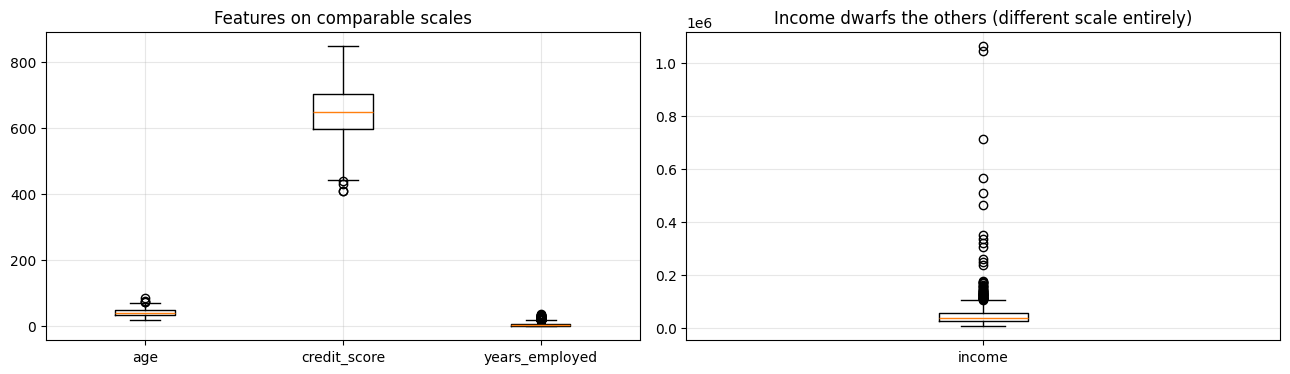

age range:        [18.0, 86.2]
income range:      [6222, 1065514]
credit_score range: [408, 850]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(
    [df['age'], df['credit_score'], df['years_employed']],
    tick_labels=['age', 'credit_score', 'years_employed']
)
axes[0].set_title('Features on comparable scales')

axes[1].boxplot([df['income']], tick_labels=['income'])
axes[1].set_title('Income dwarfs the others (different scale entirely)')

plt.tight_layout()
plt.show()

print(f"age range:        [{df['age'].min():.1f}, {df['age'].max():.1f}]")
print(f"income range:      [{df['income'].min():.0f}, {df['income'].max():.0f}]")
print(f"credit_score range: [{df['credit_score'].min():.0f}, {df['credit_score'].max():.0f}]")


## 3. Scaling Techniques

Scaling changes the **range** of a feature without changing its distribution's
shape (no change to skewness). All scalers below are fit on training data only
and applied to any new data with the *same* learned parameters — this is
critical to avoid data leakage.

### 3.1 Min-Max Scaling

Rescales a feature to a fixed range, typically $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Sensitive to outliers (a single extreme value compresses everything else).


In [4]:
def minmax_scale_manual(x, feature_range=(0, 1)):
    x = np.asarray(x, dtype=float)
    x_min, x_max = x.min(), x.max()
    x_std = (x - x_min) / (x_max - x_min)
    lo, hi = feature_range
    return x_std * (hi - lo) + lo

# Manual vs sklearn on 'age'
manual = minmax_scale_manual(df['age'].values)
sk = MinMaxScaler().fit_transform(df[['age']]).flatten()

print("Manual vs sklearn match:", np.allclose(manual, sk))
print(f"Manual range: [{manual.min():.4f}, {manual.max():.4f}]")


Manual vs sklearn match: True
Manual range: [0.0000, 1.0000]


### 3.2 Standardization (Z-score)

Centers a feature at mean 0 with unit variance:

$$x' = \frac{x - \mu}{\sigma}$$

This is the default choice for most linear models, PCA, and SVMs, since it
doesn't bound the range but does equalize variance. Not robust to outliers
(both $\mu$ and $\sigma$ are outlier-sensitive).


In [5]:
def standardize_manual(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std()

manual = standardize_manual(df['credit_score'].values)
sk = StandardScaler().fit_transform(df[['credit_score']]).flatten()

print("Manual vs sklearn match:", np.allclose(manual, sk))
print(f"Manual mean: {manual.mean():.6f}, std: {manual.std():.6f}")


Manual vs sklearn match: True
Manual mean: 0.000000, std: 1.000000


### 3.3 MaxAbs Scaling

Divides by the maximum absolute value, mapping into $[-1, 1]$ while
preserving sparsity (zeros stay zero) — useful for sparse data:

$$x' = \frac{x}{|x|_{\max}}$$

### 3.4 Robust Scaling

Uses the median and interquartile range (IQR) instead of mean/std, so
outliers barely affect the transform:

$$x' = \frac{x - \text{median}(x)}{\text{IQR}(x)}, \quad \text{IQR} = Q_3 - Q_1$$


In [6]:
def robust_scale_manual(x):
    x = np.asarray(x, dtype=float)
    median = np.median(x)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x - median) / iqr

manual = robust_scale_manual(df['income'].values)
sk = RobustScaler().fit_transform(df[['income']]).flatten()

print("Manual vs sklearn match:", np.allclose(manual, sk))


Manual vs sklearn match: True


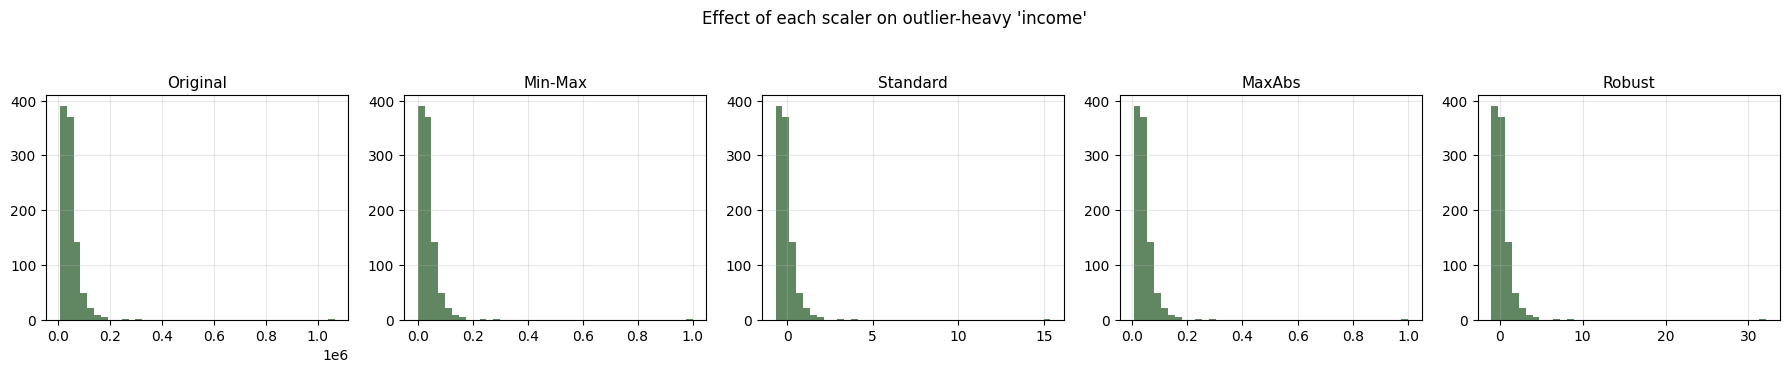

Notice: Min-Max and Standard both get compressed toward 0 because
15 extreme outliers stretch the range/variance. Robust is unaffected.


In [7]:
# Compare all four scalers on the outlier-heavy 'income' feature
scalers = {
    'Original': df[['income']].values.flatten(),
    'Min-Max': MinMaxScaler().fit_transform(df[['income']]).flatten(),
    'Standard': StandardScaler().fit_transform(df[['income']]).flatten(),
    'MaxAbs': MaxAbsScaler().fit_transform(df[['income']]).flatten(),
    'Robust': RobustScaler().fit_transform(df[['income']]).flatten(),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, (name, vals) in zip(axes, scalers.items()):
    ax.hist(vals, bins=40, color='#2C5F2D', alpha=0.75)
    ax.set_title(name, fontsize=11)
plt.suptitle("Effect of each scaler on outlier-heavy 'income'", y=1.05)
plt.tight_layout()
plt.show()

print("Notice: Min-Max and Standard both get compressed toward 0 because")
print("15 extreme outliers stretch the range/variance. Robust is unaffected.")


## 4. Normalization (Vector Norm Scaling)

**Normalization** (in the strict sklearn sense) is distinct from scaling:
it rescales *rows* (samples) so each row vector has unit norm, rather than
rescaling *columns* (features). It matters when the direction of a feature
vector is more meaningful than its magnitude — e.g. text embeddings, or
comparing samples by cosine similarity.

$$x'_i = \frac{x_i}{\|x\|_p}$$

- **L1 norm**: $\|x\|_1 = \sum_i |x_i|$ — rows sum (in absolute value) to 1
- **L2 norm**: $\|x\|_2 = \sqrt{\sum_i x_i^2}$ — rows have unit Euclidean length
- **Max norm**: $\|x\|_\infty = \max_i |x_i|$ — rows scaled by their largest element


In [8]:
def normalize_manual(X, norm='l2'):
    X = np.asarray(X, dtype=float)
    if norm == 'l1':
        norms = np.abs(X).sum(axis=1, keepdims=True)
    elif norm == 'l2':
        norms = np.sqrt((X ** 2).sum(axis=1, keepdims=True))
    elif norm == 'max':
        norms = np.abs(X).max(axis=1, keepdims=True)
    else:
        raise ValueError(norm)
    norms[norms == 0] = 1  # avoid divide-by-zero for all-zero rows
    return X / norms

X_num = df[['age', 'credit_score', 'years_employed']].values

for norm in ['l1', 'l2', 'max']:
    manual = normalize_manual(X_num, norm=norm)
    sk = Normalizer(norm=norm).fit_transform(X_num)
    print(f"{norm.upper():4s} norm — manual vs sklearn match:", np.allclose(manual, sk))

# Confirm L2-normalized rows really do have unit length
l2 = Normalizer(norm='l2').fit_transform(X_num)
row_norms = np.sqrt((l2 ** 2).sum(axis=1))
print(f"\nSample of row L2 norms after normalization: {row_norms[:5].round(6)}")


L1   norm — manual vs sklearn match: True
L2   norm — manual vs sklearn match: True
MAX  norm — manual vs sklearn match: True

Sample of row L2 norms after normalization: [1. 1. 1. 1. 1.]


## 5. Distribution-Shaping Transforms

Scaling changes range; these transforms change **shape** — usually to
reduce skewness and make a distribution closer to Gaussian, which helps
linear models, and is a hard requirement for models that assume normality.

### 5.1 Log Transform

$$x' = \log(x + c)$$

The constant $c$ (often 1) avoids $\log(0)$. Only valid for positive data.
Compresses large values much more than small ones, taming right skew.

### 5.2 Box-Cox Transform

A parametrized family that includes log as a special case:

$$
x'(\lambda) =
\begin{cases}
\dfrac{x^\lambda - 1}{\lambda} & \lambda \neq 0 \\[4pt]
\ln(x) & \lambda = 0
\end{cases}
$$

$\lambda$ is chosen (by maximum likelihood) to make the output as
Gaussian as possible. **Requires strictly positive input.**

### 5.3 Yeo-Johnson Transform

Like Box-Cox but defined for zero and negative values too — a piecewise
extension:

$$
x'(\lambda) =
\begin{cases}
\dfrac{(x+1)^\lambda - 1}{\lambda} & \lambda \neq 0,\ x \geq 0 \\[4pt]
\ln(x+1) & \lambda = 0,\ x \geq 0 \\[4pt]
-\dfrac{(-x+1)^{2-\lambda} - 1}{2-\lambda} & \lambda \neq 2,\ x < 0 \\[4pt]
-\ln(-x+1) & \lambda = 2,\ x < 0
\end{cases}
$$

### 5.4 Quantile Transform

Maps values to a target distribution (uniform or normal) via the empirical
CDF — non-parametric, and the most aggressive at forcing a specific shape.


In [9]:
def log_transform_manual(x, c=1.0):
    return np.log(np.asarray(x, dtype=float) + c)

income = df['income'].values

log_manual = log_transform_manual(income, c=1.0)

# Box-Cox (scipy) vs sklearn PowerTransformer(method='box-cox')
bc_scipy, lam_scipy = stats.boxcox(income)
bc_sklearn = PowerTransformer(method='box-cox', standardize=False).fit(income.reshape(-1, 1))
lam_sklearn = bc_sklearn.lambdas_[0]

print(f"Box-Cox lambda (scipy):   {lam_scipy:.4f}")
print(f"Box-Cox lambda (sklearn): {lam_sklearn:.4f}")
print("Transformed values match:",
      np.allclose(bc_scipy, bc_sklearn.transform(income.reshape(-1, 1)).flatten(), atol=1e-4))

# Yeo-Johnson handles data that might include zero/negative (simulate a centered feature)
centered_feature = df['age'].values - df['age'].mean()  # now has negative values
yj = PowerTransformer(method='yeo-johnson', standardize=False)
yj_out = yj.fit_transform(centered_feature.reshape(-1, 1)).flatten()
print(f"\nYeo-Johnson lambda: {yj.lambdas_[0]:.4f}  (works despite negative inputs)")

# Quantile transform to a normal distribution
qt = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
qt_out = qt.fit_transform(income.reshape(-1, 1)).flatten()


Box-Cox lambda (scipy):   -0.1789
Box-Cox lambda (sklearn): -0.1789
Transformed values match: True

Yeo-Johnson lambda: 0.9696  (works despite negative inputs)


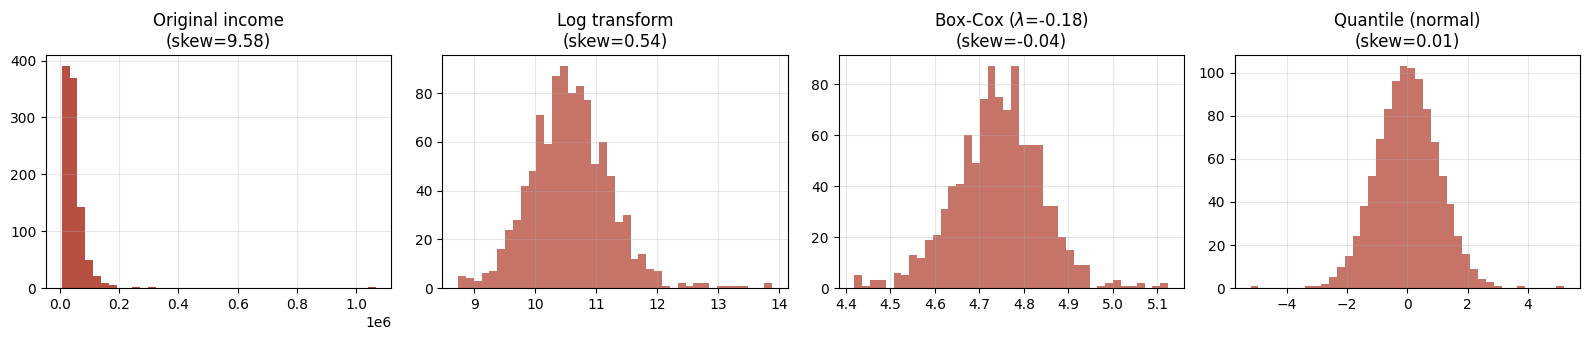

Box-Cox and Quantile both drive skewness close to 0; Box-Cox does it
with one interpretable parameter, Quantile with none but at the cost
of being a black-box, non-invertible-in-closed-form mapping.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

axes[0].hist(income, bins=40, color='#B85042')
axes[0].set_title(f'Original income\n(skew={stats.skew(income):.2f})')

axes[1].hist(log_manual, bins=40, color='#B85042', alpha=0.8)
axes[1].set_title(f'Log transform\n(skew={stats.skew(log_manual):.2f})')

axes[2].hist(bc_scipy, bins=40, color='#B85042', alpha=0.8)
axes[2].set_title(f'Box-Cox ($\\lambda$={lam_scipy:.2f})\n(skew={stats.skew(bc_scipy):.2f})')

axes[3].hist(qt_out, bins=40, color='#B85042', alpha=0.8)
axes[3].set_title(f'Quantile (normal)\n(skew={stats.skew(qt_out):.2f})')

plt.tight_layout()
plt.show()

print("Box-Cox and Quantile both drive skewness close to 0; Box-Cox does it")
print("with one interpretable parameter, Quantile with none but at the cost")
print("of being a black-box, non-invertible-in-closed-form mapping.")


## 6. Encoding Categorical Variables

Most models require numeric input, so categorical features need encoding.
The right choice depends on whether categories are **ordinal** (have a
natural order) or **nominal** (no order).

### 6.1 One-Hot Encoding

Creates one binary column per category. Correct for nominal data — avoids
imposing a false numeric order — but increases dimensionality linearly
with cardinality.

### 6.2 Ordinal Encoding

Maps each category to an integer. Only appropriate when categories have
a genuine order (e.g. education level); otherwise it fabricates a
distance relationship that isn't real.

### 6.3 Target / Mean Encoding (mention)

Replaces a category with the mean of the target variable for that
category. Powerful for high-cardinality features but leaks target
information if not done with proper cross-validation folds — shown here
conceptually only, not used in the pipeline below.


In [11]:
# One-hot: region is nominal (no natural order)
ohe = OneHotEncoder(sparse_output=False, drop=None)
region_ohe = ohe.fit_transform(df[['region']])
region_ohe_df = pd.DataFrame(region_ohe, columns=ohe.get_feature_names_out(['region']))
print("One-hot encoded 'region':")
print(region_ohe_df.head())

# Ordinal: education has a genuine order
edu_order = [['High School', 'Bachelors', 'Masters', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
edu_ordinal = oe.fit_transform(df[['education']])
print("\nOrdinal encoded 'education' (first 10):", edu_ordinal[:10].flatten())


One-hot encoded 'region':
   region_East  region_North  region_South  region_West
0          1.0           0.0           0.0          0.0
1          0.0           0.0           1.0          0.0
2          0.0           0.0           0.0          1.0
3          1.0           0.0           0.0          0.0
4          0.0           0.0           1.0          0.0

Ordinal encoded 'education' (first 10): [2. 1. 2. 0. 1. 2. 1. 1. 3. 1.]


In [12]:
# Conceptual illustration of target/mean encoding (NOT leak-safe as written —
# in practice always compute this per fold, never on the full dataset at once)
target_demo = (df['income'] > df['income'].median()).astype(int)  # a synthetic 'target'
mean_encoding_map = pd.Series(target_demo).groupby(df['region']).mean()
print("Mean-encoding map for 'region' (illustration only):")
print(mean_encoding_map)


Mean-encoding map for 'region' (illustration only):
region
East     0.545082
North    0.488959
South    0.483333
West     0.482412
Name: income, dtype: float64


## 7. Outlier-Robust Transformations

Beyond `RobustScaler` (Section 3.4), two other common approaches:

### 7.1 Winsorization (Clipping)

Caps extreme values at a percentile threshold rather than removing them —
preserves sample size while limiting the influence of extreme points:

$$x' = \text{clip}(x, \ Q_p,\ Q_{1-p})$$

### 7.2 Robust Z-score (Median Absolute Deviation)

A robust alternative to the standard z-score, replacing mean/std with
median/MAD:

$$
\text{MAD} = \text{median}(|x_i - \text{median}(x)|), \qquad
x' = \frac{0.6745 (x - \text{median}(x))}{\text{MAD}}
$$

The constant $0.6745$ makes MAD-based z-scores comparable in scale to
standard z-scores under normality, since $\text{MAD} \approx 0.6745\sigma$
for a normal distribution.


In [13]:
def winsorize_manual(x, limits=(0.05, 0.05)):
    x = np.asarray(x, dtype=float)
    lo, hi = np.percentile(x, [limits[0] * 100, 100 - limits[1] * 100])
    return np.clip(x, lo, hi)

def robust_zscore_manual(x):
    x = np.asarray(x, dtype=float)
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    return 0.6745 * (x - median) / mad

income = df['income'].values

winsorized = winsorize_manual(income, limits=(0.02, 0.02))
robust_z = robust_zscore_manual(income)
standard_z = standardize_manual(income)

print(f"Original max:      {income.max():,.0f}")
print(f"Winsorized max:    {winsorized.max():,.0f}  (capped at 98th percentile)")
print(f"\nMax |z-score| with standard scaling: {np.abs(standard_z).max():.2f}")
print(f"Max |z-score| with robust MAD scaling: {np.abs(robust_z).max():.2f}")
print("Robust z flags outliers far more sharply since the scale estimate")
print("itself isn't inflated by those same outliers.")


Original max:      1,065,514
Winsorized max:    157,017  (capped at 98th percentile)

Max |z-score| with standard scaling: 15.38
Max |z-score| with robust MAD scaling: 48.08
Robust z flags outliers far more sharply since the scale estimate
itself isn't inflated by those same outliers.


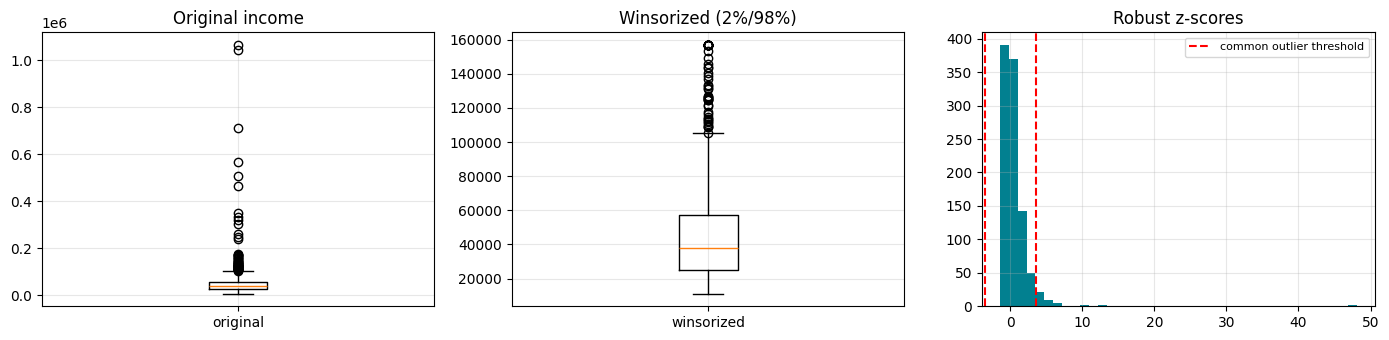

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].boxplot([income], tick_labels=['original'])
axes[0].set_title('Original income')
axes[1].boxplot([winsorized], tick_labels=['winsorized'])
axes[1].set_title('Winsorized (2%/98%)')
axes[2].hist(robust_z, bins=40, color='#028090')
axes[2].axvline(3.5, color='red', linestyle='--', label='common outlier threshold')
axes[2].axvline(-3.5, color='red', linestyle='--')
axes[2].set_title('Robust z-scores')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Dimensionality-Reduction Transforms: PCA and Whitening

PCA is a **linear transformation** that rotates data into a new coordinate
system aligned with directions of maximum variance (principal components).
It is itself a data transformation technique, not just a dimensionality
reduction tool.

### 8.1 PCA

Given standardized data $X$ (mean-centered, and typically variance-scaled),
PCA finds the eigenvectors of the covariance matrix:

$$\Sigma = \frac{1}{n-1} X^\top X = V \Lambda V^\top$$

Projecting onto the eigenvectors $V$ gives uncorrelated components ordered
by explained variance:

$$X_{\text{pca}} = XV$$

### 8.2 Whitening (Sphering)

Whitening goes one step further than PCA: it also rescales each component
to unit variance, producing a transformed feature set with an **identity
covariance matrix** — all components uncorrelated *and* equal variance:

$$X_{\text{white}} = X V \Lambda^{-1/2}$$

**ZCA whitening** is a variant that additionally rotates back into the
original feature space (multiplying by $V^\top$ again), so whitened
features stay maximally correlated with the original ones — useful when
you want decorrelated data that still visually/interpretably resembles
the input (common in image preprocessing).


In [15]:
# Standardize first -- PCA is scale-sensitive
X_num = df[['age', 'income', 'credit_score', 'years_employed']].values
X_std = StandardScaler().fit_transform(X_num)

# --- From-scratch PCA via eigendecomposition of the covariance matrix ---
cov = np.cov(X_std, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)  # ascending order
order = np.argsort(eigvals)[::-1]        # sort descending
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

X_pca_manual = X_std @ eigvecs

# --- sklearn PCA ---
pca = PCA(n_components=4)
X_pca_sklearn = pca.fit_transform(X_std)

# Sign of eigenvectors is arbitrary, so compare absolute values / explained variance
print("Explained variance ratio (manual): ", (eigvals / eigvals.sum()).round(4))
print("Explained variance ratio (sklearn):", pca.explained_variance_ratio_.round(4))
print("\nComponent-wise correlation (manual vs sklearn, should be +/-1):")
for i in range(4):
    corr = np.corrcoef(X_pca_manual[:, i], X_pca_sklearn[:, i])[0, 1]
    print(f"  PC{i+1}: {corr:.4f}")


Explained variance ratio (manual):  [0.2655 0.2525 0.2453 0.2367]
Explained variance ratio (sklearn): [0.2655 0.2525 0.2453 0.2367]

Component-wise correlation (manual vs sklearn, should be +/-1):
  PC1: -1.0000
  PC2: -1.0000
  PC3: 1.0000
  PC4: 1.0000


In [16]:
# --- Whitening (PCA whitening): rescale each component to unit variance ---
X_white_manual = X_pca_manual / np.sqrt(eigvals)

pca_white = PCA(n_components=4, whiten=True)
X_white_sklearn = pca_white.fit_transform(X_std)

print("Covariance of whitened data (manual) -- should be ~identity:")
print(np.cov(X_white_manual, rowvar=False).round(3))

print("\nCovariance of whitened data (sklearn) -- should be ~identity:")
print(np.cov(X_white_sklearn, rowvar=False).round(3))


Covariance of whitened data (manual) -- should be ~identity:
[[ 1. -0. -0.  0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

Covariance of whitened data (sklearn) -- should be ~identity:
[[ 1. -0.  0. -0.]
 [-0.  1. -0. -0.]
 [ 0. -0.  1.  0.]
 [-0. -0.  0.  1.]]


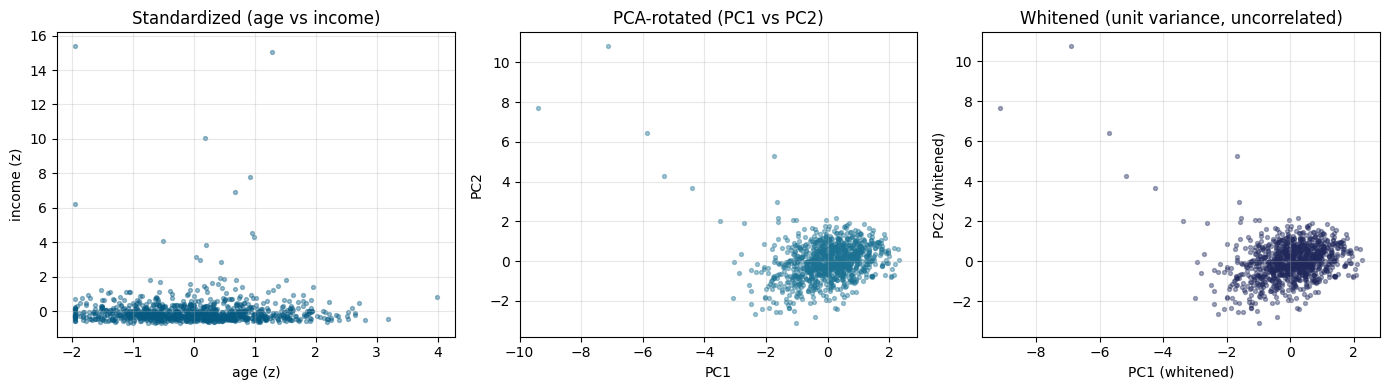

PCA rotates axes to align with variance; whitening additionally
equalizes the spread along every axis, producing a roughly circular cloud.


In [17]:
# --- ZCA whitening: rotate whitened components back into original feature space ---
X_zca = X_white_manual @ eigvecs.T

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(X_std[:, 0], X_std[:, 1], s=8, alpha=0.4, color='#065A82')
axes[0].set_title('Standardized (age vs income)')
axes[0].set_xlabel('age (z)'); axes[0].set_ylabel('income (z)')

axes[1].scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], s=8, alpha=0.4, color='#1C7293')
axes[1].set_title('PCA-rotated (PC1 vs PC2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

axes[2].scatter(X_white_manual[:, 0], X_white_manual[:, 1], s=8, alpha=0.4, color='#21295C')
axes[2].set_title('Whitened (unit variance, uncorrelated)')
axes[2].set_xlabel('PC1 (whitened)'); axes[2].set_ylabel('PC2 (whitened)')

plt.tight_layout()
plt.show()

print("PCA rotates axes to align with variance; whitening additionally")
print("equalizes the spread along every axis, producing a roughly circular cloud.")


## 9. Time-Series-Specific Transforms

Time-ordered data needs transforms that respect temporal structure —
shuffling or fitting statistics across the full series (instead of only
on past data) leaks future information into the past.

### 9.1 Differencing

Removes trend by looking at changes between consecutive observations,
often required to make a series stationary:

$$\Delta x_t = x_t - x_{t-1}$$

### 9.2 Rolling Statistics

Smooth local noise and expose trend/volatility using a moving window of
size $w$:

$$
\bar{x}_t = \frac{1}{w}\sum_{i=0}^{w-1} x_{t-i}, \qquad
s_t = \sqrt{\frac{1}{w-1}\sum_{i=0}^{w-1}(x_{t-i} - \bar{x}_t)^2}
$$

### 9.3 Lag Features

Turn a single time series into a supervised-learning table by using past
values as predictors of the current value — the basis of classical
autoregressive modeling and most ML time-series pipelines.

### 9.4 Expanding-Window Scaling

For online / streaming settings, an important rule: whichever scaler you
use, fit it **only on past data** (expanding or rolling window), never on
the whole series at once, or you leak future statistics into training.


In [18]:
# Simulate a simple time series: a trend + seasonality + noise
T = 200
t = np.arange(T)
trend = 0.05 * t
seasonality = 3 * np.sin(2 * np.pi * t / 20)
noise = np.random.normal(0, 1, T)
series = 20 + trend + seasonality + noise
ts = pd.Series(series, name='value')

# 1. Differencing
diff = ts.diff().dropna()

# 2. Rolling statistics
window = 10
rolling_mean = ts.rolling(window).mean()
rolling_std = ts.rolling(window).std()

# 3. Lag features -> supervised learning table
def make_lag_features(series, n_lags=5):
    df_lags = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags.dropna()

lag_df = make_lag_features(ts, n_lags=5)
print("Lag-feature table (first 5 rows):")
print(lag_df.head())


Lag-feature table (first 5 rows):
           y      lag_1      lag_2      lag_3      lag_4      lag_5
5  24.331870  22.384866  22.898066  23.481582  20.824787  17.886334
6  24.060393  24.331870  22.384866  22.898066  23.481582  20.824787
7  24.048630  24.060393  24.331870  22.384866  22.898066  23.481582
8  22.847254  24.048630  24.060393  24.331870  22.384866  22.898066
9  22.262953  22.847254  24.048630  24.060393  24.331870  22.384866


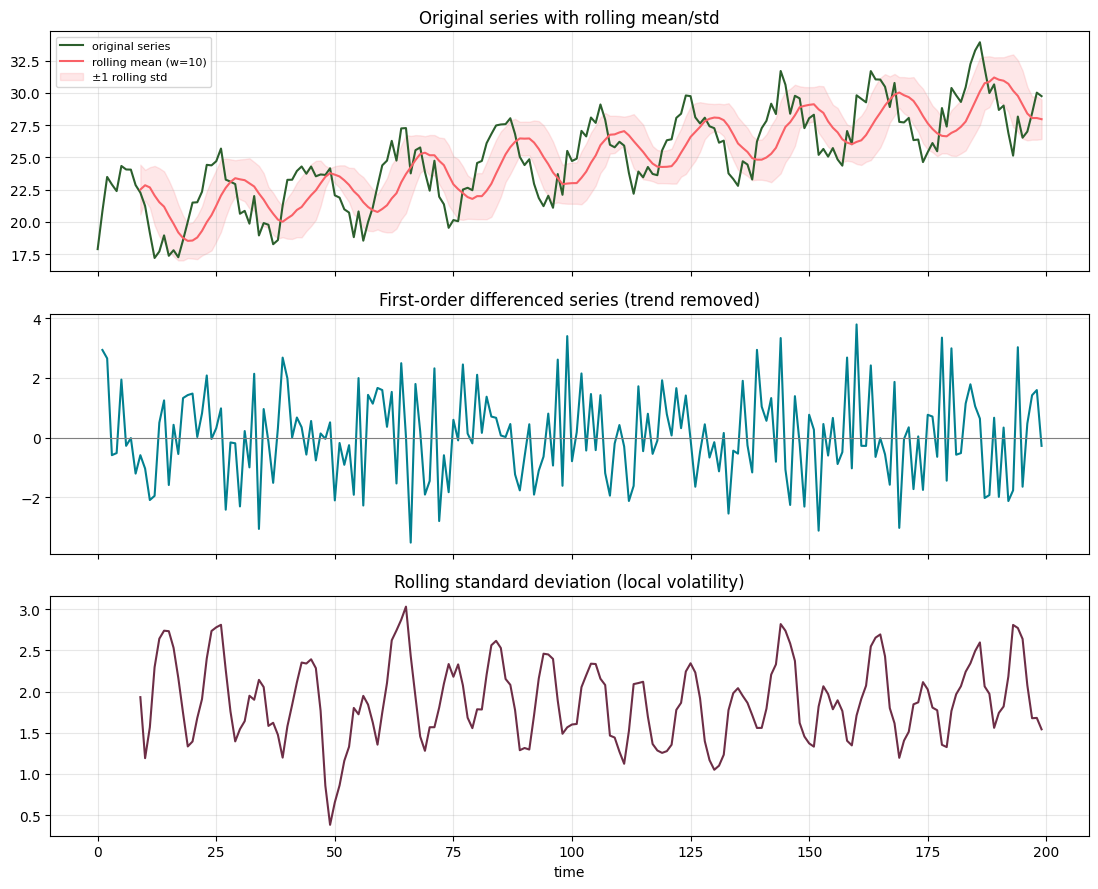

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(t, ts, color='#2C5F2D', label='original series')
axes[0].plot(t, rolling_mean, color='#F96167', label=f'rolling mean (w={window})')
axes[0].fill_between(t,
                      rolling_mean - rolling_std,
                      rolling_mean + rolling_std,
                      color='#F96167', alpha=0.15, label='±1 rolling std')
axes[0].set_title('Original series with rolling mean/std')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(diff.index, diff.values, color='#028090')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('First-order differenced series (trend removed)')

axes[2].plot(t, rolling_std, color='#6D2E46')
axes[2].set_title('Rolling standard deviation (local volatility)')
axes[2].set_xlabel('time')

plt.tight_layout()
plt.show()


In [20]:
# Expanding-window (leak-free) standardization for streaming/online use
def expanding_standardize(series):
    """
    Standardize each point using only statistics available up to (and
    including) that point -- safe for online / walk-forward evaluation.
    First point is undefined (no prior variance) and returned as NaN.
    """
    expanding_mean = series.expanding().mean()
    expanding_std = series.expanding().std()
    return (series - expanding_mean) / expanding_std

expanding_z = expanding_standardize(ts)

print("First 8 expanding-window z-scores (note: index 0 is NaN, no variance yet):")
print(expanding_z.head(8).round(3).values)
print("\nCompare to naive full-series standardization (LEAKS future stats into the past):")
naive_z = (ts - ts.mean()) / ts.std()
print(naive_z.head(8).round(3).values)
print("\nThese differ substantially early in the series -- the expanding version")
print("only 'knows' what a model deployed at that time would have known.")


First 8 expanding-window z-scores (note: index 0 is NaN, no variance yet):
[  nan 0.707 0.983 0.643 0.396 1.019 0.794 0.714]

Compare to naive full-series standardization (LEAKS future stats into the past):
[-2.005 -1.178 -0.43  -0.595 -0.739 -0.191 -0.267 -0.271]

These differ substantially early in the series -- the expanding version
only 'knows' what a model deployed at that time would have known.


## 10. Putting It Together: A Full `ColumnTransformer` Pipeline

In practice you rarely apply transforms as one-off function calls — you
compose them into a single `ColumnTransformer` so that:

- Every column gets the transform appropriate to its type/distribution
- The exact same fitted transform is reapplied to new/test/production data
- The whole thing can be embedded inside a `Pipeline` with a model at the
  end, so cross-validation properly refits transforms per fold (avoiding
  leakage)


In [21]:
numeric_normal = ['age', 'credit_score']       # roughly symmetric -> StandardScaler
numeric_skewed = ['income']                      # skewed, has outliers -> PowerTransformer
numeric_positive_skewed = ['years_employed']     # skewed, positive -> PowerTransformer
categorical_nominal = ['region']                 # OneHotEncoder
categorical_ordinal_col = ['education']          # OrdinalEncoder with explicit order

preprocessor = ColumnTransformer(transformers=[
    ('scale_normal', StandardScaler(), numeric_normal),
    ('power_income', PowerTransformer(method='yeo-johnson'), numeric_skewed),
    ('power_employed', PowerTransformer(method='yeo-johnson'), numeric_positive_skewed),
    ('onehot_region', OneHotEncoder(sparse_output=False), categorical_nominal),
    ('ordinal_edu', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]),
        categorical_ordinal_col),
])

X_transformed = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()

result_df = pd.DataFrame(X_transformed, columns=feature_names)
print(f"Transformed shape: {result_df.shape}")
result_df.head()


Transformed shape: (1000, 9)


,scale_normal__age,scale_normal__credit_score,power_income__income,power_employed__years_employed,onehot_region__region_East,onehot_region__region_North,onehot_region__region_South,onehot_region__region_West,ordinal_edu__education
0,0.488673,-0.696697,1.162819,1.018316,1.0,0.0,0.0,0.0,2.0
1,-0.173588,-0.150976,0.769197,1.998744,0.0,0.0,1.0,0.0,1.0
2,0.646134,-0.817267,-0.001690,-0.695091,0.0,0.0,0.0,1.0,2.0
3,1.559084,-0.319058,-0.686702,1.817346,1.0,0.0,0.0,0.0,0.0
4,-0.273597,-1.949717,0.574283,-0.134718,0.0,0.0,1.0,0.0,1.0


In [22]:
# Sanity check: transformed numeric columns should now be roughly standardized
print("Post-transform summary stats (numeric columns):")
print(result_df[[c for c in feature_names if 'onehot' not in c and 'ordinal' not in c]]
      .describe().T[['mean', 'std', 'min', 'max']].round(3))

print("\nThis ColumnTransformer can now be dropped straight into a Pipeline:")
print("""
model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', SomeEstimator())
])
model_pipeline.fit(X_train, y_train)   # transforms are fit ONLY on training folds
""")


Post-transform summary stats (numeric columns):
                                mean    std    min    max
scale_normal__age                0.0  1.001 -1.941  3.989
scale_normal__credit_score       0.0  1.001 -3.108  2.569
power_income__income            -0.0  1.001 -3.304  3.912
power_employed__years_employed   0.0  1.001 -2.018  2.444

This ColumnTransformer can now be dropped straight into a Pipeline:

model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', SomeEstimator())
])
model_pipeline.fit(X_train, y_train)   # transforms are fit ONLY on training folds



## 11. Summary / Decision Guide

| Situation | Recommended transform |
|---|---|
| Features on very different scales, roughly Gaussian, no major outliers | `StandardScaler` |
| Need a bounded range (e.g. neural net inputs, image pixels) | `MinMaxScaler` |
| Sparse data that must stay sparse | `MaxAbsScaler` |
| Heavy outliers present | `RobustScaler`, winsorization, or MAD z-score |
| Right-skewed, strictly positive data | Log transform or Box-Cox |
| Skewed data that includes zero/negative values | Yeo-Johnson |
| Want to force a specific target distribution, non-parametrically | `QuantileTransformer` |
| Row vectors compared by direction/cosine similarity | `Normalizer` (L1/L2/Max) |
| Nominal categorical feature | One-hot encoding |
| Ordinal categorical feature | Ordinal encoding (explicit order) |
| High-cardinality categorical, supervised setting | Target/mean encoding (with proper CV) |
| Correlated features, want decorrelated components | PCA |
| Want decorrelated **and** equal-variance components | PCA whitening / ZCA |
| Time series with trend | Differencing |
| Time series, want smoothed/local statistics | Rolling mean/std |
| Time series -> supervised learning table | Lag features |
| Time series, online/streaming deployment | Expanding-window statistics (never fit on future data) |

### Key principles to remember

1. **Always fit on training data only**, then apply the same fitted
   transform to validation/test/production data — refitting on new data
   is a common and subtle leakage bug.
2. **Scaling and shape-transforms address different problems** — pick
   both when needed (e.g. Box-Cox to fix skew, *then* StandardScaler to
   fix scale).
3. **Outlier-robust variants exist for most techniques** — check whether
   your data has extreme values before defaulting to mean/std-based
   methods.
4. **Time series is a special case**: any transform that uses global
   statistics (min, max, mean over the whole series) can leak future
   information into the past unless computed on an expanding/rolling
   window.
